<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Matplotlib_fundamental_histogram_boxplot_lineplot_area_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Data Visualization**
___
Data visualization is the presentation of data in an image or graphical format. Data visualization can also be defined as the discipline of understanding data by presenting it visually so that any patterns or trends, composition, comparisons, and relationships can be exposed.

We can use data visualization to explore data and find insights from it. We can also share our findings with others using data visualization. The human brain processes any information more easily using visualizations than spreadsheets or reports.


In [ ]:
# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# settings
import warnings
warnings.filterwarnings('ignore')

## **1. Why is data visualization necessary?**

So far, we've focused a lot on summarizing data using statistics. However, summary statistics aren't enough to understand a distribution; there are many possible distributions for a given set of summary statistics. Data visualization is necessary to truly understand the distribution:

![DataSaurus Dozen.gif](<https://github.com/harishmuh/Python-for-Data-Science-Analysis/blob/main/Assets/DataSaurus%20Dozen.gif?raw=true>)

It's difficult to find patterns and gain insights from raw data. Statistics can summarize data, but they may hide patterns in the data distribution.

## **2. Why start with Matplotlib?**

There are many libraries for creating data visualizations in Python (even more if you include libraries built on top of them). In this section, we'll explore Matplotlib's role in the Python data visualization ecosystem before delving deeper into it.

<figure>
  <blockquote cite="https://matplotlib.org/stable/index.html" style="border-left: none; box-shadow: none;">
    Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. &#91;It&#93; makes easy things easy and hard things possible.
  </blockquote>
  <figcaption style="text-align: right">&ndash; <a href="https://matplotlib.org/stable/index.html" target="_blank" rel="noopener noreferrer">Matplotlib documentation</a></figcaption>
</figure>

We'll start by using the `stackoverflow_monthly.csv` dataset, which contains the titles and tags for all Stack Overflow questions tagged with a few selected Python libraries since Stack Overflow's inception (September 2008) through September 12, 2021. The data comes from the [Stack Overflow API](https://api.stackexchange.com/docs/search).

In [ ]:
stackoverflow_monthly = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTZ5fVQvljweLhF-lJPpiK0LQvkP0Wgplu4f3HhdGTSHRjz1YglYpx7isOv54Pd_BmW-4PeX4i2HntV/pub?gid=197735777&single=true&output=csv', parse_dates=True, index_col='creation_date')
stackoverflow_monthly.sample(5)

,pandas,matplotlib,numpy,seaborn,geopandas,geoviews,altair,yellowbrick,vega,holoviews,hvplot,bokeh
creation_date,,,,,,,,,,,,
2020-06-30,4862,1019,1475,212,44,1,40,1,10,9,5,67
2013-11-30,356,317,486,0,1,0,0,0,1,0,0,0
2010-01-31,0,16,21,0,0,0,0,0,0,0,0,0
2019-06-30,2882,568,898,97,30,3,16,1,4,15,4,69
2013-05-31,226,240,362,0,0,0,0,0,1,0,0,0


Next, we plot the monthly Matplotlib queries over time by calling the `plot()` method:

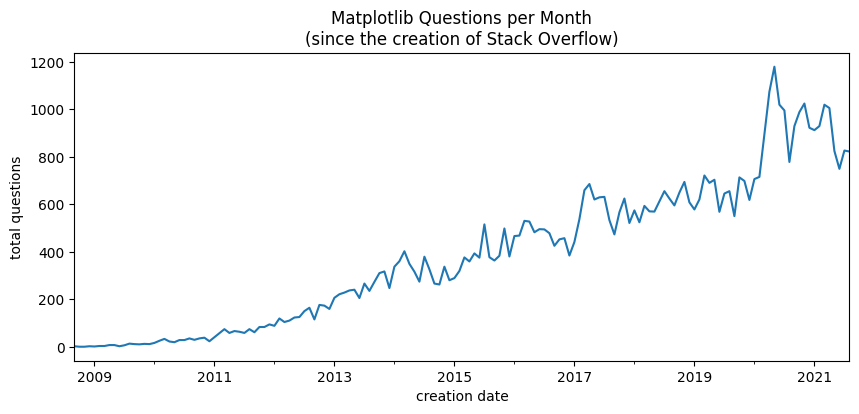

In [ ]:
stackoverflow_monthly['matplotlib'].plot( # Pandas plot, by default a line plot
    figsize=(10,4), # Sets the size of the figure or canvas (length, height)
    xlabel="creation date", # Adds labels to the x-axis
    ylabel="total questions", # Adds labels to the y-axis
    title = "Matplotlib Questions per Month\n(since the creation of Stack Overflow)" # Adds title
)

plt.show()
# We can use the kind=... parameter to change the graph type ('hist' for a histogram, 'box' for a boxplot, etc.)

Note that this method returns a Matplotlib `Axes` object because pandas uses Matplotlib as its plotting backend. This means that pandas does a lot of the work for us; some examples include the following:

- Creating a figure: [source code](https://github.com/pandas-dev/pandas/blob/f5c224215ad0b3728173c67330ffcf13b35bdb2e/pandas/plotting/_matplotlib/core.py#L373-L392)
- Calling the `Axes.plot()` method: [source code](https://github.com/pandas-dev/pandas/blob/f5c224215ad0b3728173c67330ffcf13b35bdb2e/pandas/plotting/_matplotlib/core.py#L759-L760)
- Adding a title/label ... [source](https://github.com/pandas-dev/pandas/blob/f5c224215ad0b3728173c67330ffcf13b35bdb2e/pandas/plotting/_matplotlib/core.py#L576-L591)

While Pandas can do a lot of the work for us, it's helpful to understand how to work with Matplotlib directly.

#### `Flexibility`

We can use other data structures (such as NumPy arrays) without having to convert to pandas data structures just to create a plot.

#### `Customization`

Even though we used pandas to create the initial plot, we can use Matplotlib commands on the `Axes` object to change other parts of the visualization. This also applies to any library that uses Matplotlib as its plotting backend; Examples include:
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/): geospatial data processing to produce map visualizations
- [ggplot](https://github.com/yhat/ggplot): Python version of the popular `ggplot2` R package
- [HoloViews](http://holoviews.org/): interactive visualizations with minimal code
- [Seaborn](https://seaborn.pydata.org/): high-level interface for creating statistical visualizations with Matplotlib
- [Yellowbrick](https://www.scikit-yb.org/): Scikit-Learn extension for creating visualizations for analyzing machine learning performance

*Note: Matplotlib maintains a list of these libraries [here](https://matplotlib.org/stable/thirdpartypackages/index.html).*

#### `Extensibility`

You can also build your own personal/work library based on Matplotlib. This might mean defining a theme or custom plotting functions to create commonly used visualizations.

Furthermore, if you want to contribute to open-source data visualization libraries (as mentioned above), knowledge of Matplotlib will be useful. An example is the addition of the `refline()` method to the Seaborn library. This method allows you to draw horizontal/vertical reference lines on all subplots at once. The Matplotlib methods `axhline()` and `axvline()` are the basis of [this contribution](https://github.com/mwaskom/seaborn/commit/a626c0ae29b8c777b8e1342948e1611b984bf27b):

<div style="text-align: center;">
<img width="60%" src="https://pbs.twimg.com/media/FBSw8BPX0AAa3wn?format=jpg&name=medium" alt="Seaborn refline() example" style="min-width: 300px">
<div><small><em><a href="https://twitter.com/chris1610/status/1446976863365124098">Source</a></em></small></div>
</div>

## **3. Matplotlib Basic**

The `Figure` object is the container for all our visualization components. It contains one or more `Axes` objects, which can be thought of as (sub)plots, as well as other [*Artists*](https://matplotlib.org/stable/tutorials/intermediate/artists.html) objects, which draw on the plot canvas (x-axis, y-axis, legend, lines, etc.). The following image from the Matplotlib documentation illustrates the various components of a `Figure`:

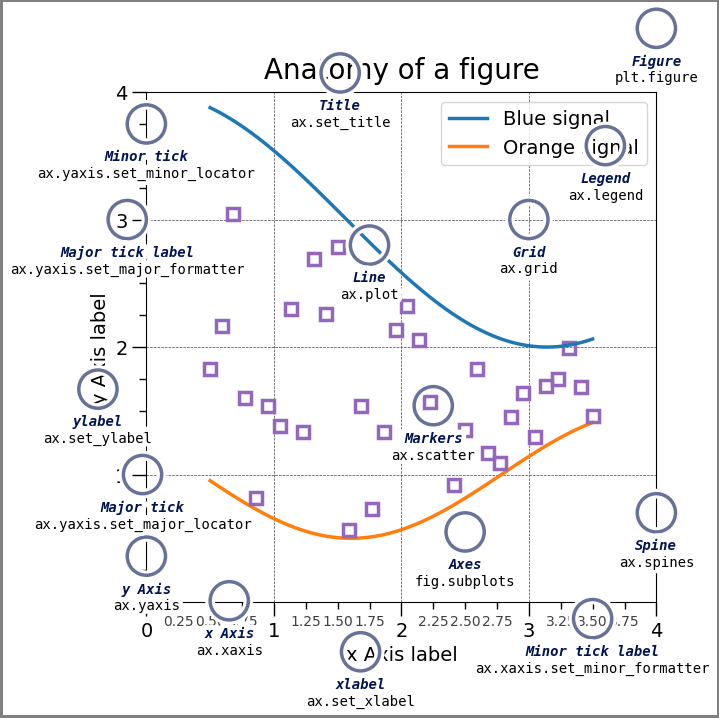

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

royal_blue = [0, 20/256, 82/256]


# make the figure

np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_axes([0.2, 0.17, 0.68, 0.7], aspect=1)

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter("{x:.2f}")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0, length=10, labelsize=14)
ax.tick_params(which='minor', width=1.0, length=5, labelsize=10,
               labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c='C0', lw=2.5, label="Blue signal", zorder=10)
ax.plot(X, Y2, c='C1', lw=2.5, label="Orange signal")
ax.plot(X[::3], Y3[::3], linewidth=0, markersize=9,
        marker='s', markerfacecolor='none', markeredgecolor='C4',
        markeredgewidth=2.5)

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("x Axis label", fontsize=14)
ax.set_ylabel("y Axis label", fontsize=14)
ax.legend(loc="upper right", fontsize=14)


# Annotate the figure

def annotate(x, y, text, code):
    # Circle marker
    c = Circle((x, y), radius=0.15, clip_on=False, zorder=10, linewidth=2.5,
               edgecolor=royal_blue + [0.6], facecolor='none',
               path_effects=[withStroke(linewidth=7, foreground='white')])
    ax.add_artist(c)

    # use path_effects as a background for the texts
    # draw the path_effects and the colored text separately so that the
    # path_effects cannot clip other texts
    for path_effects in [[withStroke(linewidth=7, foreground='white')], []]:
        color = 'white' if path_effects else royal_blue
        ax.text(x, y-0.2, text, zorder=100,
                ha='center', va='top', weight='bold', color=color,
                style='italic', fontfamily='monospace',
                path_effects=path_effects)

        color = 'white' if path_effects else 'black'
        ax.text(x, y-0.33, code, zorder=100,
                ha='center', va='top', weight='normal', color=color,
                fontfamily='monospace', fontsize='medium',
                path_effects=path_effects)


annotate(3.5, -0.13, "Minor tick label", "ax.xaxis.set_minor_formatter")
annotate(-0.03, 1.0, "Major tick", "ax.yaxis.set_major_locator")
annotate(0.00, 3.75, "Minor tick", "ax.yaxis.set_minor_locator")
annotate(-0.15, 3.00, "Major tick label", "ax.yaxis.set_major_formatter")
annotate(1.68, -0.39, "xlabel", "ax.set_xlabel")
annotate(-0.38, 1.67, "ylabel", "ax.set_ylabel")
annotate(1.52, 4.15, "Title", "ax.set_title")
annotate(1.75, 2.80, "Line", "ax.plot")
annotate(2.25, 1.54, "Markers", "ax.scatter")
annotate(3.00, 3.00, "Grid", "ax.grid")
annotate(3.60, 3.58, "Legend", "ax.legend")
annotate(2.5, 0.55, "Axes", "fig.subplots")
annotate(4, 4.5, "Figure", "plt.figure")
annotate(0.65, 0.01, "x Axis", "ax.xaxis")
annotate(0, 0.36, "y Axis", "ax.yaxis")
annotate(4.0, 0.7, "Spine", "ax.spines")

# frame around figure
fig.patch.set(linewidth=4, edgecolor='0.5')
plt.show()


Matplotlib provides two primary approaches for plotting interfaces:
1. Functional (implicit): Calling functions provided by the `pyplot` module.
2. Object-oriented (explicit): Calling methods on the `Figure` and `Axes` objects.

While the object-oriented approach is encouraged by Matplotlib and highly recommended for non-interactive use (i.e., outside of Jupyter Notebook), either approach is valid – however, you should avoid mixing the two. Note that different use cases require different approaches, so we will explore examples of both in this section.

### `Functional (implicit) approach`

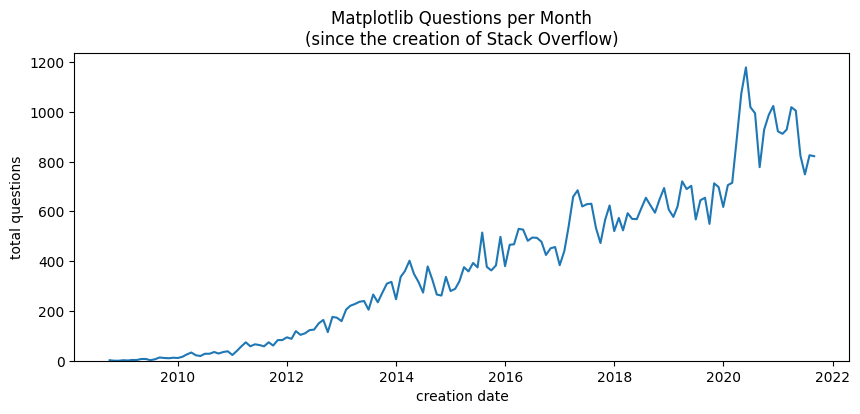

In [ ]:
plt.figure(figsize=(10,4)) # Set the figure size
plt.plot(stackoverflow_monthly.index, stackoverflow_monthly['matplotlib'])

plt.xlabel('creation date') # Add a label to the x-axis
plt.ylabel('total questions') # Add a label to the y-axis
plt.title("Matplotlib Questions per Month\n(since the creation of Stack Overflow)") # Add a title

plt.ylim(0, None)

plt.show()

#### `Object-oriented (explicit) approach`

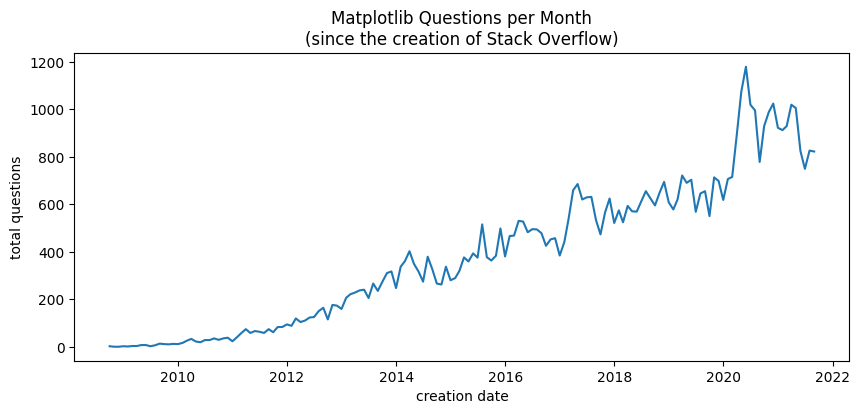

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
stackoverflow_monthly.index, # x-axis
stackoverflow_monthly['matplotlib'] # y-axis
)

ax.set_xlabel('creation date') # add labels to the x-axis
ax.set_ylabel('total questions') # add labels to the y-axis
ax.set_title("Matplotlib Questions per Month\n(since the creation of Stack Overflow)")
plt.show()

*Tip: Note that each plotting command returns something. This is a Matplotlib object that we can also use to further customize the visualization.*

As mentioned earlier, we can use Matplotlib code to modify the plots that pandas creates for us. Here, we'll use an object-oriented approach to remove the top and right spines and start the y-axis at 0, while retaining the current settings at the end:

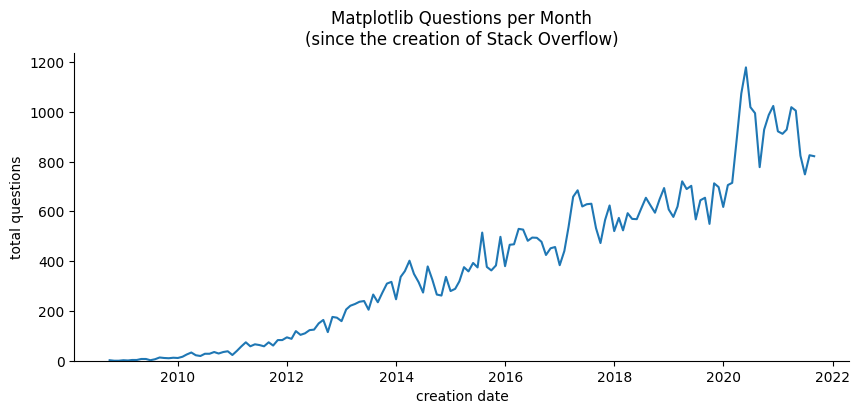

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
stackoverflow_monthly.index, # x-axis
stackoverflow_monthly['matplotlib'] # y-axis
)

ax.set_xlabel('creation date') # add labels to the x-axis
ax.set_ylabel('total questions') # add labels to the y-axis
ax.set_title("Matplotlib Questions per Month\n(since the creation of Stack Overflow)")

ax.set_ylim(0, None) # set the limits of the y-axis

ax.spines['top'].set_visible(False) # remove the top spine line
ax.spines['right'].set_visible(False) # remove the right spine line

plt.show()

*Tip: You can use a functional approach to change the y-axis limits by replacing `ax.set_ylim(0, None)` with `plt.ylim(0, None)`.*

Now that we've mastered the basics, let's look at how to create other types of plots and add additional components to them, such as legends, reference lines, and annotations. Note that the anatomy of a figure plot we looked at earlier will help you transition from idea to implementation by identifying the right keywords to search for. It might also be helpful to bookmark this Matplotlib cheat sheet [https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Python_Matplotlib_Cheat_Sheet.pdf](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Python_Matplotlib_Cheat_Sheet.pdf).

## **4. Plotting with Matplotlib**

Now that we understand a bit about how Matplotlib works, we'll cover some more involved examples, including legends, reference lines, and/or annotations, and build them step by step. Note that while using a library like pandas to create the initial plots can make things easier, we'll focus on using Matplotlib exclusively to better understand it.

Each example in this section will show you how to create a specific plot directly with Matplotlib and how to customize it with some of the more advanced plotting techniques available. Specifically, we'll learn how to create and customize the following plot types:

- histograms
- box plots
- line plots
- area plots
- scatter plots
- bar plots
- stacked bar plots


## **5. Histogram**

A histogram is used to display data distribution (either frequency or density). In general, a histogram can show the frequency (the number of data points that appear) within a certain range of values. A histogram is a univariate (one variable) numeric visualization method.

The new dataset we will be working with contains NYC subway entrances and exits per borough per day for 2017-2021. The data was resampled from [this](https://www.kaggle.com/eddeng/nyc-subway-traffic-data-20172021?select=NYC_subway_traffic_2017-2021.csv). Our dataset looks like this:

In [ ]:
NYC_subway_daily = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/NYC_subway_daily.csv'
subway = pd.read_csv(NYC_subway_daily, index_col=['Borough', 'Datetime'], parse_dates=['Datetime'])
subway_daily = subway.unstack(0)
subway_daily.head()

Entries                                    Exits            \
Borough            Bk        Bx          M         Q        Bk        Bx   
Datetime                                                                   
2017-02-04   617650.0  247539.0  1390496.0  408736.0  417449.0  148237.0   
2017-02-05   542667.0  199078.0  1232537.0  339716.0  405607.0  139856.0   
2017-02-06  1184916.0  472846.0  2774016.0  787206.0  761166.0  267991.0   
2017-02-07  1192638.0  470573.0  2892462.0  790557.0  763653.0  270007.0   
2017-02-08  1243658.0  497412.0  2998897.0  825679.0  788356.0  275695.0   

                                 
Borough             M         Q  
Datetime                         
2017-02-04  1225689.0  279699.0  
2017-02-05  1033610.0  268626.0  
2017-02-06  2240027.0  537780.0  
2017-02-07  2325024.0  544828.0  
2017-02-08  2389534.0  559639.0

We will create a histogram of daily subway entries in Manhattan with this data using the following steps:
1. Create the histogram.
2. Label and format the plot.
3. Explore the use of subplots.
4. Apply a style sheet.

#### `1. Create the histogram.`
To create a histogram, we use the `hist()` method:

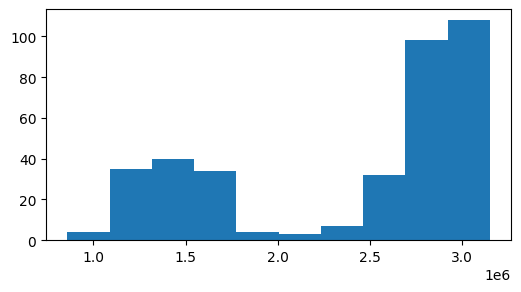

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(subway_daily.loc['2018', 'Entries']['M'], ec='black')
plt.show()

#### `2. Label and format the plot.`
Next, we clean up the plot by labeling the axes and formatting the tick labels. The `matplotlib.ticker` module contains classes for tick location and formatting for data types other than dates.

In [ ]:
from matplotlib import ticker

Next, we'll create a utility function to make removing the top and right spines of our plots easier in the future. Returning an `Axes` object is considered good practice:

In [ ]:
def despine(ax):

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    return ax


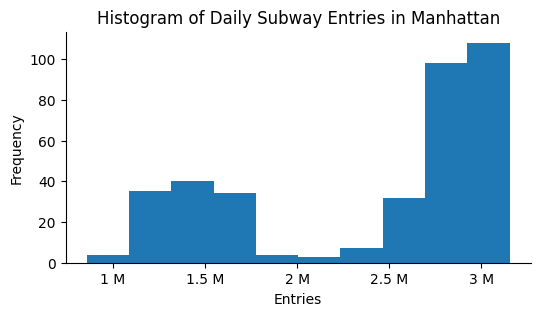

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))                              # define figure and axes

ax.hist(subway_daily.loc['2018', 'Entries']['M'], ec='black')       # plot histogram
ax.set(
    xlabel='Entries',                                               # label x-axis
    ylabel='Frequency',                                             # label y-axis
    title='Histogram of Daily Subway Entries in Manhattan'          # title
)

ax.xaxis.set_major_formatter(ticker.EngFormatter())

despine(ax)
plt.show()

#### `3. Explore the use of subplots.`
The histogram of daily subway entries in Manhattan shows a distinctly bimodal distribution. Let's use a subplot to separate the weekday and weekend distributions, which combine to produce the shape we see.

First, we need to create a Boolean Mask to filter the data by weekday versus weekend:

In [ ]:
weekday_mask = subway_daily.index.weekday < 5
weekday_mask

array([False, False,  True, ...,  True,  True,  True])

In [ ]:
# data on weekdays
subway_daily[weekday_mask]

Entries                                    Exits            \
Borough            Bk        Bx          M         Q        Bk        Bx   
Datetime                                                                   
2017-02-06  1184916.0  472846.0  2774016.0  787206.0  761166.0  267991.0   
2017-02-07  1192638.0  470573.0  2892462.0  790557.0  763653.0  270007.0   
2017-02-08  1243658.0  497412.0  2998897.0  825679.0  788356.0  275695.0   
2017-02-09   634546.0  242587.0  1656711.0  422201.0  458342.0  163598.0   
2017-02-10  1183652.0  467586.0  2889220.0  784178.0  742926.0  258144.0   
...               ...       ...        ...       ...       ...       ...   
2021-08-09   416964.0  176407.0   836603.0  316604.0  438273.0  168791.0   
2021-08-10   439452.0  178417.0   889912.0  330299.0  462818.0  174888.0   
2021-08-11   442855.0  183132.0   899173.0  331304.0  464905.0  175388.0   
2021-08-12   438576.0  178191.0   884371.0  327306.0  463303.0  172487.0   
2021-08-13   346768.0  151257.0   639806.0  268861.0  332156.0  121962.0   

                                 
Borough             M         Q  
Datetime                         
2017-02-06  2240027.0  537780.0  
2017-02-07  2325024.0  544828.0  
2017-02-08  2389534.0  559639.0  
2017-02-09  1369515.0  327995.0  
2017-02-10  2356212.0  521273.0  
...               ...       ...  
2021-08-09  1032724.0  322343.0  
2021-08-10  1109777.0  339166.0  
2021-08-11  1124608.0  337363.0  
2021-08-12  1116445.0  332967.0  
2021-08-13   875206.0  229383.0  

[1180 rows x 8 columns]

In [ ]:
# data on weekends
subway_daily[~weekday_mask]

Entries                                    Exits            \
Borough           Bk        Bx          M         Q        Bk        Bx   
Datetime                                                                  
2017-02-04  617650.0  247539.0  1390496.0  408736.0  417449.0  148237.0   
2017-02-05  542667.0  199078.0  1232537.0  339716.0  405607.0  139856.0   
2017-02-11  696640.0  271909.0  1673553.0  469597.0  518630.0  177017.0   
2017-02-12  512749.0  180774.0  1160066.0  316296.0  394384.0  130073.0   
2017-02-18  681833.0  264228.0  1604580.0  457835.0  494304.0  175942.0   
...              ...       ...        ...       ...       ...       ...   
2021-07-25  236419.0   87983.0   500714.0  175323.0  294334.0  100656.0   
2021-07-31  308718.0  117623.0   640786.0  229407.0  370447.0  123292.0   
2021-08-01  239149.0   86506.0   489900.0  178685.0  300630.0  100190.0   
2021-08-07  295063.0  114845.0   622757.0  218397.0  356289.0  123696.0   
2021-08-08  229737.0   86651.0   485802.0  168298.0  291696.0  100982.0   

                                 
Borough             M         Q  
Datetime                         
2017-02-04  1225689.0  279699.0  
2017-02-05  1033610.0  268626.0  
2017-02-11  1396952.0  370791.0  
2017-02-12   975341.0  267283.0  
2017-02-18  1328629.0  359421.0  
...               ...       ...  
2021-07-25   688256.0  206722.0  
2021-07-31   876198.0  263330.0  
2021-08-01   677082.0  211648.0  
2021-08-07   856301.0  251441.0  
2021-08-08   669864.0  201742.0  

[472 rows x 8 columns]

Next, we need to update our call to `plt.subplots()` to specify a single row of two columns as our layout, with all subplots sharing the same x-axis range (`sharex=True`). Since there are fewer weekend days than weekdays in a year, we won't share the y-axis (`sharey=False`). As before, we call the `hist()` method to add a histogram to each subplot:

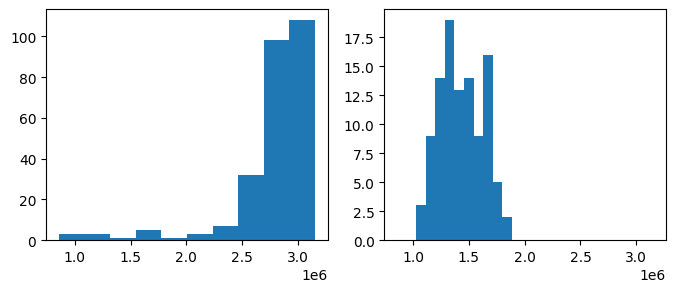

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=False) # 1 is the row, 2 is the column

axes[0].hist(subway_daily[weekday_mask].loc['2018', 'Entries']['M'], ec='black')
axes[1].hist(subway_daily[~weekday_mask].loc['2018', 'Entries']['M'], ec='black')

plt.show()

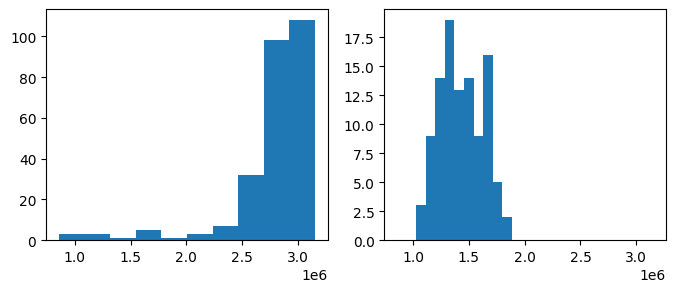

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=False) # 1 is the row, 2 is the column

for ax, mask in zip(axes, [weekday_mask, ~weekday_mask]):
  ax.hist(subway_daily[mask].loc['2018', 'Entries']['M'], ec='black')

plt.show()

Now, let's label and format the subplots. We'll use x-axis labels to distinguish between weekday and weekend distributions, and we'll only label the y-axis on the leftmost plot to reduce clutter. This requires us to include the labels in our `for` loop. Here, we also update the formatting of the x-axis tick labels to use engineering notation:

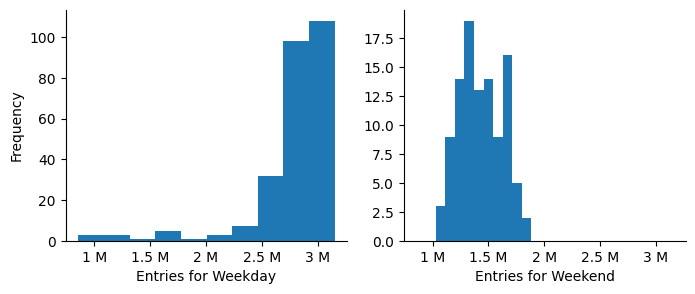

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=False) # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.hist(subway_daily[mask].loc['2018', 'Entries']['M'], ec='black')
  ax.set_xlabel(f'Entries for {label}')
  ax.xaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency')
plt.show()

Since we have multiple subplots, we need to call the `suptitle()` method on the `Figure` object to provide a title for the entire visualization. This shows a clear shift in subway usage between weekdays and weekends, as well as the impact of congestion on bridges and tunnels:

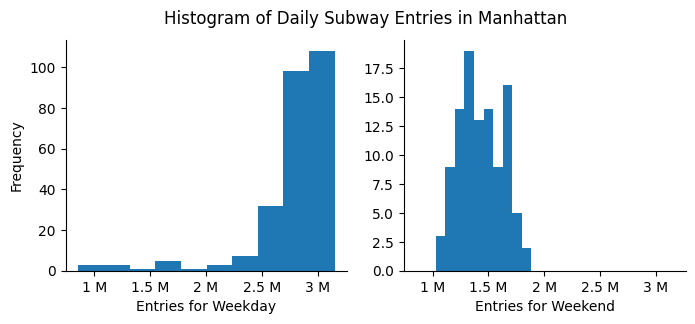

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=False) # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.hist(subway_daily[mask].loc['2018', 'Entries']['M'], ec='black')
  ax.set_xlabel(f'Entries for {label}')
  ax.xaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency') # label the y-axis of axes[0], first plot

fig.suptitle('Histogram of Daily Subway Entries in Manhattan') # gives a large title to the figure

plt.show()

Before we continue, let's wrap this code in a function. Note that we're removing the call to `despine()` because the style sheet we'll be using next already hides the spine:

In [ ]:
def subway_histogram(subway_daily, weekday_mask):

  fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=False) # 1 is the row, 2 is the column

  for ax, mask, label in zip(
    axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']
  ):
    ax.hist(subway_daily[mask].loc['2018', 'Entries']['M'], ec='black')
    ax.set_xlabel(f'Entries for {label}')
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

  axes[0].set_ylabel('Frequency') # label the y-axis of axes[0], first plot

  fig.suptitle('Histogram of Daily Subway Entries in Manhattan') # gives a large title to the figure

  return fig, axes

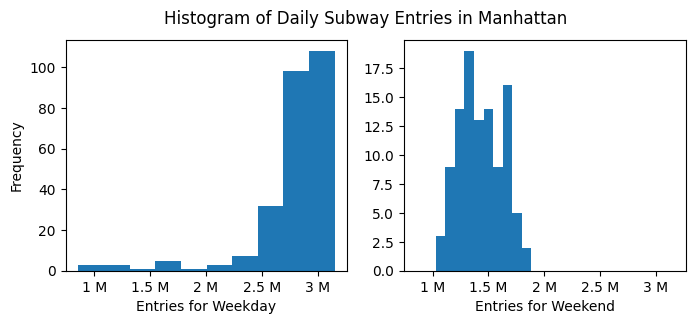

In [ ]:
subway_histogram(subway_daily, weekday_mask)
plt.show()

#### `4. Apply a style sheet`.
Matplotlib comes with a variety of [style sheet](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html) that make it easy to adjust multiple settings at once. We can activate a style sheet for a single plot using the `plt.style.context()` [context manager](https://realpython.com/python-with-statement/). Here, we apply the `seaborn-darkgrid` style sheet:

In [ ]:
style_list = ['default',
 'classic',
 'Solarize_Light2',
 'bmh',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

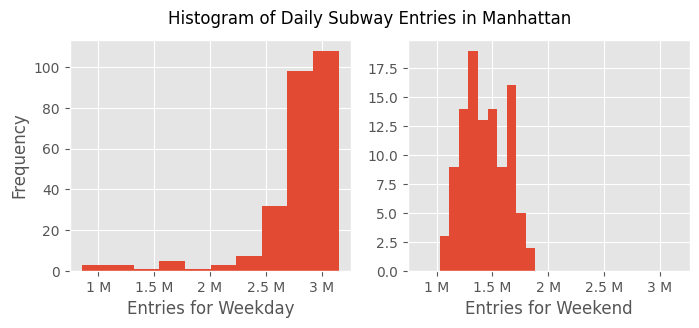

In [ ]:
with plt.style.context('ggplot'):
    subway_histogram(subway_daily, weekday_mask)

After applying this style sheet, it is a bit difficult to know where the tick marks are on the x-axis for the regions filled with bars.

## **6. Boxplot**

As an alternative to the previous visualization, we will create a boxplot. Like a histogram, a boxplot is a univariate (1 variable) numeric visualization method. Boxplots can be used to:

- Display data distribution
- Detect outliers
- View IQR
- Univariate (1 Variable) Numerical

Our initial code looks very similar – we simply call the `boxplot()` method instead of the `hist()` method:

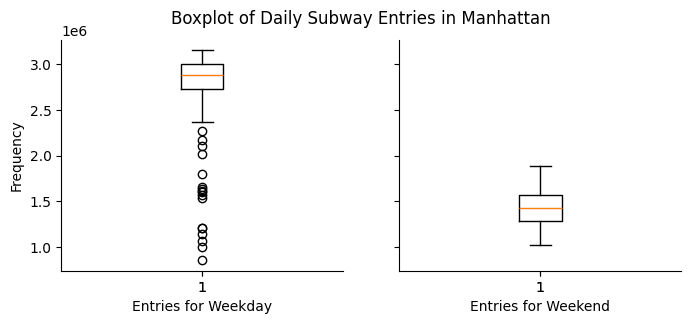

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharex=True, sharey=True) # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.boxplot(subway_daily[mask].loc['2018', 'Entries']['M'])
  ax.set_xlabel(f'Entries for {label}')
  ax.xaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency') # label the y-axis of axes[0], first plot

fig.suptitle('Boxplot of Daily Subway Entries in Manhattan') # gives a large title to the figure

plt.show()

However, this time each subplot has a single tick labeled **1**. Instead of setting the x-axis labels, we need to use the `set_xticklabels()` method:

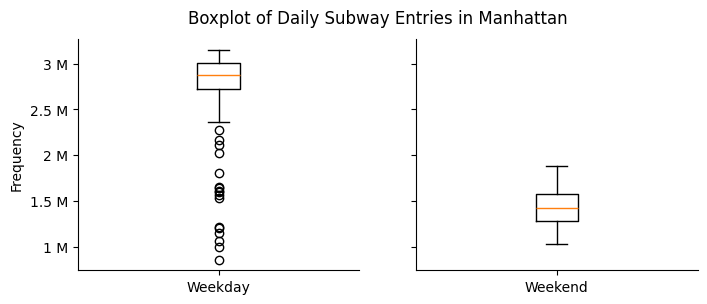

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True) # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.boxplot(subway_daily[mask].loc['2018', 'Entries']['M'])
  ax.set_xticklabels([label])
  ax.yaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency') # labels the y-axis of axes[0], the first plot

fig.suptitle('Boxplot of Daily Subway Entries in Manhattan') # gives a large title figure

plt.show()

The final change we'll cover in this section is the `tight_layout()` method, which adjusts the visualization layout to make better use of space (more information here [here](https://matplotlib.org/stable/tutorials/intermediate/tight_layout_guide.html?highlight=tight%20layout%20guide)). Note that here the spacing between subplots is reduced by adjusting the x-axis length of each subplot. This method is also useful when labels are partially obscured:

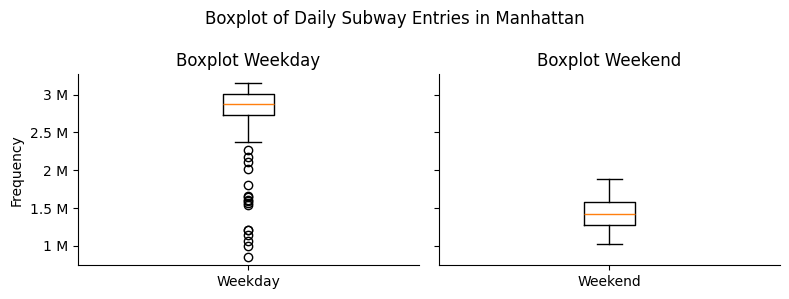

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True) # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.boxplot(subway_daily[mask].loc['2018', 'Entries']['M'])
  ax.set_xticklabels([label])
  ax.yaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency') # labels the y-axis of axes[0], the first plot

fig.suptitle('Boxplot of Daily Subway Entries in Manhattan') # gives a large title Figura

axes[0].set_title('Boxplot Weekday')
axes[1].set_title('Boxplot Weekend')

fig.tight_layout() # tightens the layout for a neater look

An alternative to tight layout is constrained layout, which uses a constraint solver to determine the placement of plot elements [more information here](https://matplotlib.org/stable/tutorials/intermediate/constrainedlayout_guide.html). Unlike tight layout, constrained layout must be enabled before we create a plot, so we need to modify the `plt.subplots()` call:

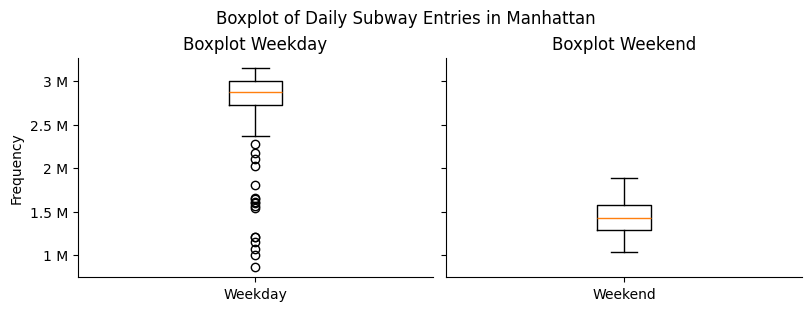

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True, layout='constrained') # 1 is the row, 2 is the column

for ax, mask, label in zip(axes, [weekday_mask, ~weekday_mask], ['Weekday', 'Weekend']):
  ax.boxplot(subway_daily[mask].loc['2018', 'Entries']['M'])
  ax.set_xticklabels([label])
  ax.yaxis.set_major_formatter(ticker.EngFormatter())
  despine(ax)

axes[0].set_ylabel('Frequency') # label the y-axis of axes[0], first plot

fig.suptitle('Boxplot of Daily Subway Entries in Manhattan') # give Large title on the figure

axes[0].set_title('Boxplot Weekday')
axes[1].set_title('Boxplot Weekend')

plt.show()

*Tip: Save any visualizations we have created by calling the `plt.savefig()` function or the `savefig()` method on a `Figure` object as the last line in the cell that generates the plot.*

## **7. Lineplot**

The Stack Overflow data we worked with earlier is time series data, so for the next visualization, we'll use a lineplot to study the evolution of the data over time.

A lineplot represents a trend/progress over a specific time period. It uses time series data (related to time). A lineplot is an example of a bivariate (2-variable) visualization to see the relationship between time series and numeric variables.

We'll use Stack Overflow data. However, instead of using monthly aggregates as before, we'll use daily data, so we'll read the stackoverflow_daily.csv data.


In [ ]:
stackoverflow_daily_csv = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/stackoverflow_daily.csv'
stackoverflow_daily = pd.read_csv(stackoverflow_daily_csv, index_col='creation_date', parse_dates=True)
stackoverflow_daily.tail()

,pandas,matplotlib,numpy,seaborn,geopandas,geoviews,altair,yellowbrick,vega,holoviews,hvplot,bokeh
creation_date,,,,,,,,,,,,
2021-09-08,132,33,49,5,2,0,2,1,1,1,0,2
2021-09-09,182,33,51,8,1,0,1,0,3,0,0,2
2021-09-10,132,19,44,7,4,0,0,0,2,0,0,2
2021-09-11,66,19,17,2,1,0,0,0,0,0,0,1
2021-09-12,69,14,24,3,0,1,0,0,0,0,0,0


We'll visualize how the average number of Matplotlib queries over the last 30 days has moved over time (a 30-day moving average), along with its standard deviation. To do this, we first need to calculate the following data points using pandas:

In [ ]:
avgs = stackoverflow_daily.rolling('30D').mean()
stds = stackoverflow_daily.rolling('30D').std()

avgs.tail()

,pandas,matplotlib,numpy,seaborn,geopandas,geoviews,altair,yellowbrick,vega,holoviews,hvplot,bokeh
creation_date,,,,,,,,,,,,
2021-09-08,136.933333,26.966667,37.133333,5.766667,1.833333,0.000000,0.500000,0.133333,0.500000,0.400000,0.033333,1.033333
2021-09-09,138.000000,27.033333,37.933333,5.766667,1.833333,0.000000,0.533333,0.133333,0.566667,0.400000,0.000000,1.033333
2021-09-10,137.100000,26.733333,37.966667,5.800000,1.833333,0.000000,0.533333,0.133333,0.566667,0.366667,0.000000,1.066667
2021-09-11,133.433333,26.400000,37.233333,5.666667,1.833333,0.000000,0.533333,0.133333,0.533333,0.333333,0.000000,1.000000
2021-09-12,130.466667,25.933333,36.666667,5.666667,1.733333,0.033333,0.533333,0.133333,0.533333,0.233333,0.000000,0.866667


Now, we can proceed to building this visualization. We will perform the following steps in the next few steps:
1. Create the line plot.
2. Add a shaded region for $\pm$ 2 standard deviations from the mean.
3. Set the axis labels, y-axis limits, plot title, and despine the plot.

#### `1. Create the line plot.`

By default, the `plot()` method will return a line plot:

In [ ]:
avgs['matplotlib']

,matplotlib
creation_date,
2008-09-08,0.000000
2008-09-09,0.000000
2008-09-10,0.000000
2008-09-11,0.000000
2008-09-12,0.000000
...,...
2021-09-08,26.966667
2021-09-09,27.033333
2021-09-10,26.733333


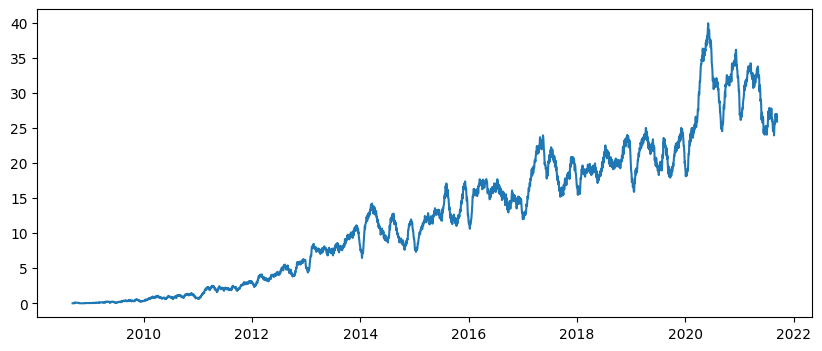

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(avgs.index, avgs['matplotlib']) # x-axis: avgs.index, y-axis: avgs['matplotlib']
plt.show()

#### `2. Add a shaded region for +/- 2 standard deviations from the mean.`

Next, we use the `fill_between()` method to shade the $\pm$ region 2 times the standard deviation from the mean. Note that we also set `alpha=0.25` to make the region 25% opaque – transparent enough to easily see the rolling 30-day average line:

In [ ]:
stds['matplotlib']

,matplotlib
creation_date,
2008-09-08,NaN
2008-09-09,0.000000
2008-09-10,0.000000
2008-09-11,0.000000
2008-09-12,0.000000
...,...
2021-09-08,7.146175
2021-09-09,7.194267
2021-09-10,7.338765


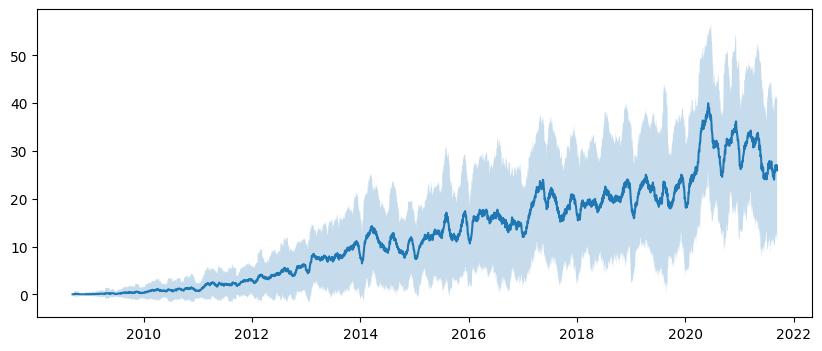

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(avgs.index, avgs['matplotlib'])         # x-axis: avgs.index,  y-axis: avgs['matplotlib']

ax.fill_between(
    avgs.index,
    avgs['matplotlib'] - 2 * stds['matplotlib'],
    avgs['matplotlib'] + 2 * stds['matplotlib'],
    alpha=0.25
)

plt.show()

#### `3. Set the axis labels, y-axis limits, plot title, and despine the plot.`

Sekarang untuk sentuhan terakhir. Jika pada contoh sebelumnya kita menggunakan `ax.set_xlabel()`, `ax.set_ylabel()`, dll., di sini kita menggunakan `ax.set()`, yang memungkinkan kita menyetel beberapa atribut plot dalam satu panggilan metode.

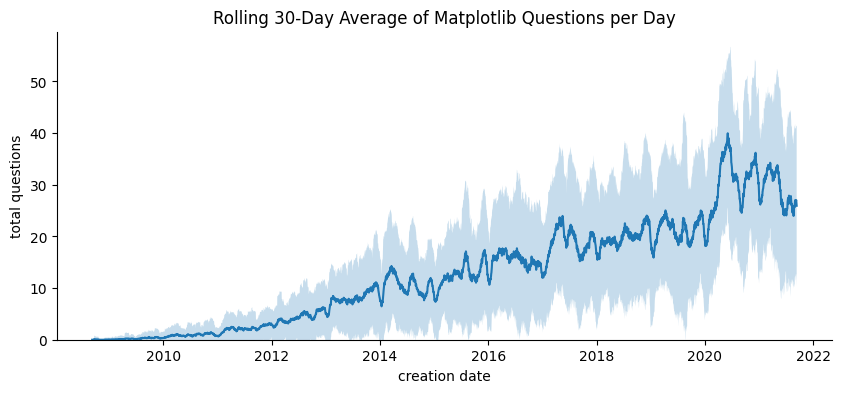

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(avgs.index, avgs['matplotlib'])         # x-axis: avgs.index,  y-axis: avgs['matplotlib']

ax.fill_between(
    avgs.index,
    avgs['matplotlib'] - 2 * stds['matplotlib'],
    avgs['matplotlib'] + 2 * stds['matplotlib'],
    alpha=0.25
)

ax.set(
    xlabel='creation date',
    ylabel='total questions',
    ylim=(0, None),
    title='Rolling 30-Day Average of Matplotlib Questions per Day'
)

despine(ax)

plt.show()

## **8. Area Plot**

We've just used a time series for Matplotlib questions, but it's also interesting to look at trends across other libraries. Because the libraries in this dataset vary in age, popularity, and number of Stack Overflow questions, an area plot is a good option for viewing many questions at once. This will give us a sense of the overall trends of this type of library and the libraries themselves. Let's start by grouping our daily Stack Overflow question data into the top four libraries by number of questions:

In [ ]:
subset = stackoverflow_daily.sum().nlargest(4)

In [ ]:
top_libraries_monthly = stackoverflow_monthly.reindex(columns=subset.index)
top_libraries_monthly.tail()

,pandas,numpy,matplotlib,seaborn
creation_date,,,,
2021-04-30,4335,1351,1005,209
2021-05-31,4217,1316,824,174
2021-06-30,4331,1214,749,166
2021-07-31,4170,1228,826,153
2021-08-31,4175,1095,822,170


Now, we can create our plot. Again, we'll break it down into several steps:
1. Create the plot area.
2. Label and format the axes, provide a title, and describe the plot.
3. Add annotations.

#### `1. Create the area plot.`

First, we use `stackplot()` to create an area plot as a starting point. However, first, we'll convert the date to Matplotlib date format. We can use the `date2num()` function in the `matplotlib.dates` module to convert the date to Matplotlib date format:

In [ ]:
import matplotlib.dates as mdates

sample = mdates.date2num(top_libraries_monthly.index)
sample

array([14152., 14183., 14213., 14244., 14275., 14303., 14334., 14364.,
       14395., 14425., 14456., 14487., 14517., 14548., 14578., 14609.,
       14640., 14668., 14699., 14729., 14760., 14790., 14821., 14852.,
       14882., 14913., 14943., 14974., 15005., 15033., 15064., 15094.,
       15125., 15155., 15186., 15217., 15247., 15278., 15308., 15339.,
       15370., 15399., 15430., 15460., 15491., 15521., 15552., 15583.,
       15613., 15644., 15674., 15705., 15736., 15764., 15795., 15825.,
       15856., 15886., 15917., 15948., 15978., 16009., 16039., 16070.,
       16101., 16129., 16160., 16190., 16221., 16251., 16282., 16313.,
       16343., 16374., 16404., 16435., 16466., 16494., 16525., 16555.,
       16586., 16616., 16647., 16678., 16708., 16739., 16769., 16800.,
       16831., 16860., 16891., 16921., 16952., 16982., 17013., 17044.,
       17074., 17105., 17135., 17166., 17197., 17225., 17256., 17286.,
       17317., 17347., 17378., 17409., 17439., 17470., 17500., 17531.,
      

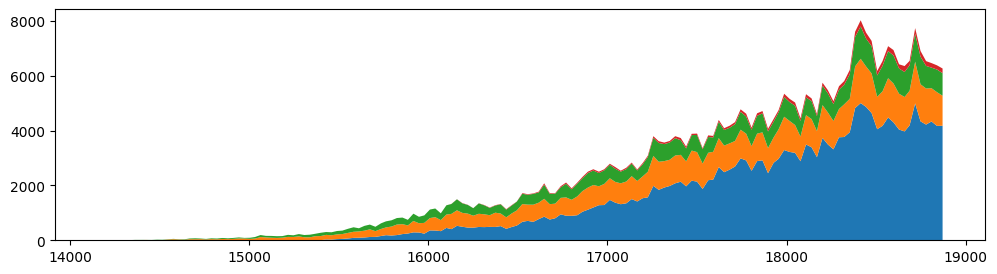

In [ ]:
fig, ax = plt.subplots(figsize=(12,3))

ax.stackplot(
    mdates.date2num(top_libraries_monthly.index),            # x-axis
    top_libraries_monthly.to_numpy().T,                      # y-axis
    labels = top_libraries_monthly.columns
)

plt.show()

#### `2. Label and format the axes, provide a title, and despine the plot.`

Next, we'll tackle labels and formatting before working on annotations. This should look familiar from the previous example:

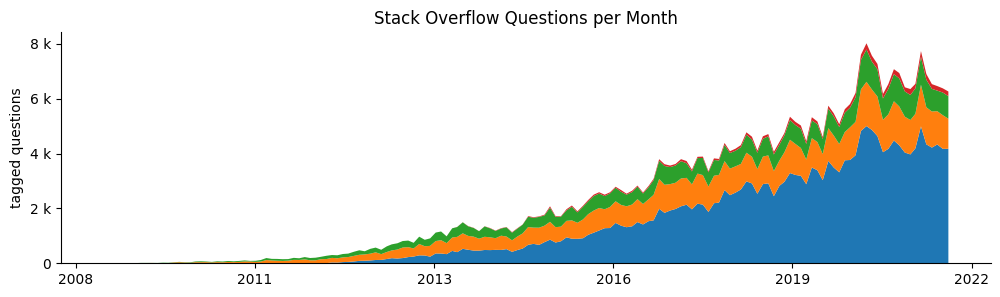

In [ ]:
fig, ax = plt.subplots(figsize=(12,3))

ax.stackplot(
    mdates.date2num(top_libraries_monthly.index),            # x axis
    top_libraries_monthly.to_numpy().T,                      # y axis
    labels = top_libraries_monthly.columns
)

ax.set(
    xlabel='',
    ylabel='tagged questions',
    title='Stack Overflow Questions per Month'
)

ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

despine(ax)

plt.show()

This will be the basis of some of the visualizations we do in this section, so let's create a function for what we have so far:

In [ ]:
def area_plot(data):

    fig, ax = plt.subplots(figsize=(12,3))

    ax.stackplot(
        mdates.date2num(data.index),            # x axis
        data.to_numpy().T,                      # y axis
        labels = data.columns
    )

    ax.set(
        xlabel='',
        ylabel='tagged questions',
        title='Stack Overflow Questions per Month'
    )

    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    despine(ax)

    return ax

<Axes: title={'center': 'Stack Overflow Questions per Month'}, ylabel='tagged questions'>

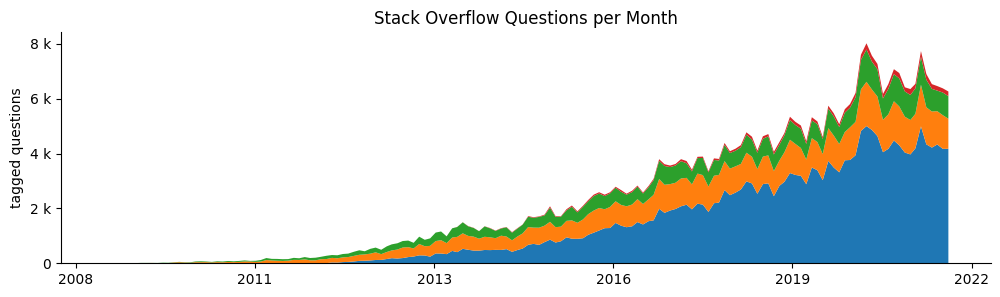

In [ ]:
area_plot(top_libraries_monthly)

#### `3. Add annotations.`

Instead of using a legend for this plot, we will use annotations to label each area and provide the median value for 2021. To create an annotation, we use the `annotate()` method with the following arguments:

- The first argument (`text`) is the annotation text as a string.
- The `xy` argument is a tuple of coordinates for the data point we are annotating.
- The `xytext` argument is a tuple of coordinates where we want to place the annotation text.
- When providing `xytext`, we can optionally provide `arrowprops`, which defines the style to be used for the arrow pointing from `xytext` to `xy`.
- We can also adjust the horizontal (`ha`) and vertical (`va`) alignment of the text.

In [ ]:
def annotate(ax, data):
    total = 0
    for area in ax.collections:
        library = area.get_label()
        last = data.last('1D')[library]
        last_day, last_value = last.index[0], last.iat[0]
        if library != 'seaborn':
            kwargs = {}
        else:
            kwargs = dict(
                xytext=(last_day + pd.Timedelta(days=20), (last_value + total) * 1.1),
                arrowprops=dict(arrowstyle='->')
            )

        ax.annotate(
            f' {library}: {data.loc["2021", library].median():,.0f}',
            xy=(last_day, last_value / 2 + total), ha='left', va='center', **kwargs
        )
        total += last_value
    return ax

Now, let's see what our plot looks like so far:

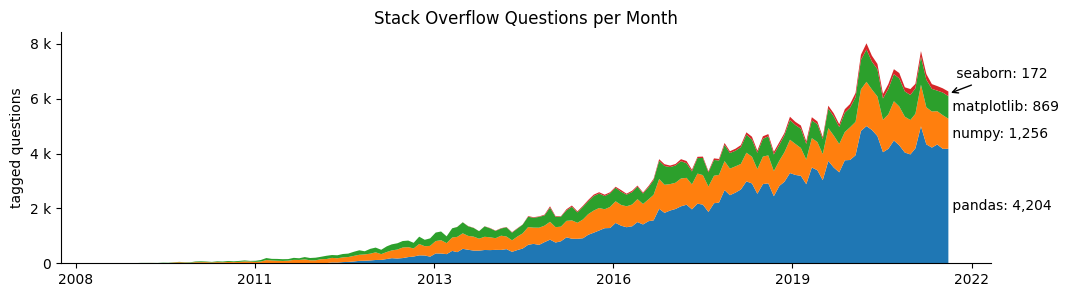

In [ ]:
ax = area_plot(top_libraries_monthly)
annotate(ax, top_libraries_monthly)
plt.show()

Before we move on to the next plot, which is built on this one, let's update our `area_plot()` function to include a call to the `annotate()` function:

In [ ]:
def area_plot(data):

    fig, ax = plt.subplots(figsize=(12,3))

    ax.stackplot(
        mdates.date2num(data.index),            # x-axis
        data.to_numpy().T,                      # y-axis
        labels = data.columns
    )

    ax.set(
        xlabel='',
        ylabel='tagged questions',
        title='Stack Overflow Questions per Month'
    )

    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    despine(ax)
    annotate(ax, data)

    return ax

#### `More Annotations`

The Stack Overflow community is very active, and we often see older questions updated with new answers reflecting the latest solutions. The dataset we've been working with contains some examples of this: Seaborn makes some plotting tasks much easier than Matplotlib, so some Stack Overflow questions currently tagged "seaborn" were originally posted before Seaborn's first release (v0.1 [https://github.com/mwaskom/seaborn/releases/tag/v0.1]) on October 28, 2013. See [Color by Column Values in Matplotlib](https://stackoverflow.com/questions/14885895/color-by-column-values-in-matplotlib](https://stackoverflow.com/questions/14885895/color-by-column-values-in-matplotlib) for an example.

Let's use the reference line and shaded region to highlight this section on an area plot.

First, we'll add a dashed vertical line for the first release of Seaborn (October 28, 2013) using the `axvline()` method:

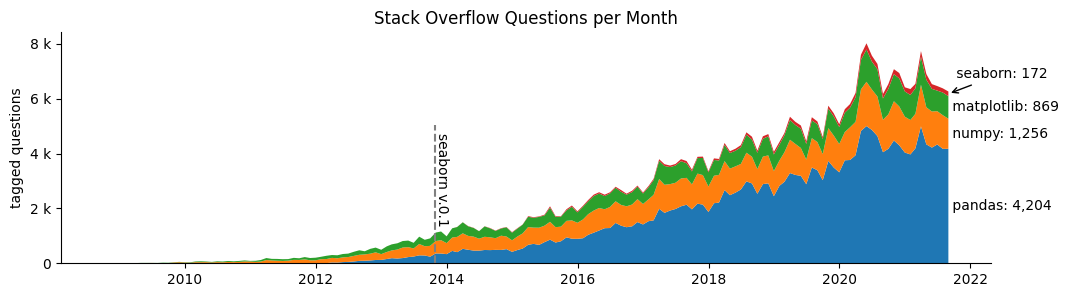

In [ ]:
import datetime as dt

seaborn_released = dt.date(2013, 10, 28)

ax = area_plot(top_libraries_monthly)

ax.axvline(seaborn_released, ymax=0.6, color='gray', linestyle='dashed')
ax.annotate('seaborn v.0.1', xy=(seaborn_released, 4750), rotation = -90, va='top')
plt.show()

Next, we'll create an additional vertical line for the oldest questions retroactively tagged "seaborn":

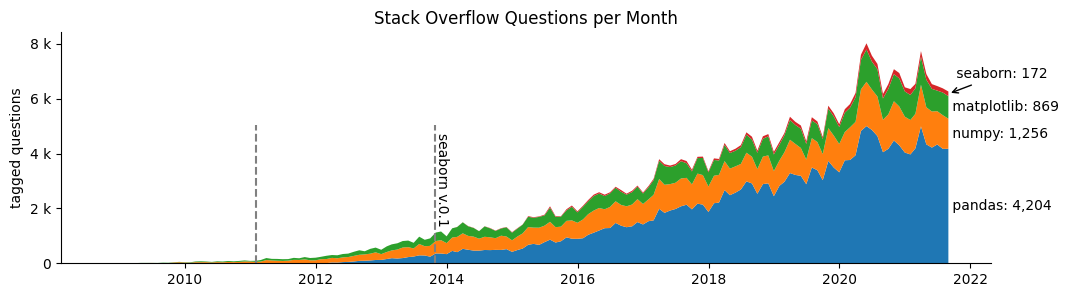

In [ ]:
ax = area_plot(top_libraries_monthly)

seaborn_released = dt.date(2013, 10, 28)
ax.axvline(seaborn_released, ymax=0.6, color='gray', linestyle='dashed')
ax.annotate('seaborn v.0.1', xy=(seaborn_released, 4750), rotation = -90, va='top')

first_seaborn_qs = top_libraries_monthly.query('seaborn >= 1').first('1D').index[0].to_pydatetime().date()
ax.axvline(first_seaborn_qs, ymax=0.6, color='gray', linestyle='dashed')
plt.show()

Let's wrap this reference line logic into a function before looking at how to shade the region between them:

In [ ]:
def add_reflines(ax, data):
  seaborn_released = dt.date(2013, 10, 28) # seaborn release date
  ax.axvline(seaborn_released, ymax=0.6, color='gray', linestyle='dashed')
  ax.annotate('seaborn v.0.1', xy=(seaborn_released, 4750), rotation = -90, va='top')

  first_seaborn_qs = data.query('seaborn >= 1').first('1D').index[0].to_pydatetime().date() # first time seaborn is queried
  ax.axvline(first_seaborn_qs, ymax=0.6, color='gray', linestyle='dashed')

  return ax

Finally, we use the `axvspan()` method to shade the area between the lines:

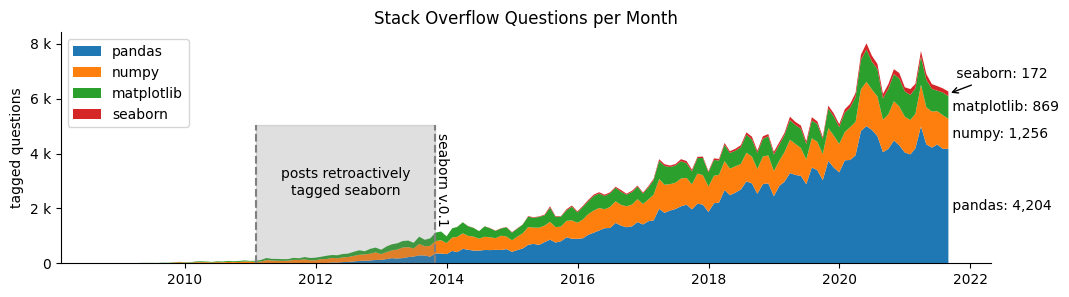

In [ ]:
ax = area_plot(top_libraries_monthly)
add_reflines(ax, top_libraries_monthly)

# Shading the area between lines
ax.axvspan(
  ymax=0.6, # y-axis limit
  xmin=mdates.date2num(first_seaborn_qs), # minimum x-axis limit
  xmax=mdates.date2num(seaborn_released), # maximum x-axis limit
  color='gray',
  alpha=0.25
)

# Adding annotations
middle = first_seaborn_qs + (seaborn_released - first_seaborn_qs)/2 # Calculating the middle value between
ax.annotate( # Adding annotations
  'posts retroactively\ntagged seaborn', # annotation text
  xy=(middle, 3500), # x and y positions in the tuple
  va='top', # vertical alignment
  ha='center' # horizontal alignment
)

ax.legend(loc='upper left') # add legend
plt.show()